In [3]:
import os

def collect_parent_ids(subset):
    base_dataset = getattr(subset, "dataset", subset)
    indices = getattr(subset, "indices", range(len(subset)))

    parent_ids = set()
    for idx in indices:
        filepath = base_dataset.samples[idx][0]
        filename = os.path.basename(filepath)
        
        # 1. Clean the prefixes
        if filename.startswith("transfer_"):
            filename = filename[len("transfer_"):]
        elif filename.startswith("redigital_"):
            filename = filename[len("redigital_"):]
            
        # 2. Strip the extension (.png or .jpg)
        parent_id, _ = os.path.splitext(filename)
        parent_ids.add(parent_id)
        
    return parent_ids

# Create the loaders if not already in memory
if 'train_loader' not in globals() or 'val_loader' not in globals() or 'test_loader' not in globals():
    from src.data.dataloader import get_dataloaders
    train_loader, val_loader, test_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Get subsets from loaders
train_subset = train_loader.dataset
val_subset = val_loader.dataset

print("Scanning Training Set (Extracting parent IDs)...")
train_parent_ids = collect_parent_ids(train_subset)

print("Scanning Validation Set (Extracting parent IDs)...")
val_parent_ids = collect_parent_ids(val_subset)

# Find the true leakage
leaked_parents = train_parent_ids.intersection(val_parent_ids)

print("\n--- TRUE LEAKAGE REPORT ---")
print(f"Unique parent images in Train: {len(train_parent_ids)}")
print(f"Unique parent images in Val:   {len(val_parent_ids)}")
print(f"TRUE LEAKED PARENT IMAGES:     {len(leaked_parents)}")

if len(leaked_parents) > 0:
    print(f"Percentage of Val subjects leaked: {(len(leaked_parents)/len(val_parent_ids))*100:.2f}%")
    print("\nExamples of leaked parent subjects:")
    for parent in list(leaked_parents)[:5]:
        print(f" - {parent}")
else:
    print("\nZero leakage! Your split is truly safe.")


Loaded 12 images.
Scanning Training Set (Extracting parent IDs)...
Scanning Validation Set (Extracting parent IDs)...

--- TRUE LEAKAGE REPORT ---
Unique parent images in Train: 9
Unique parent images in Val:   1
TRUE LEAKED PARENT IMAGES:     0

Zero leakage! Your split is truly safe.


In [4]:
from src.data.dataloader import get_dataloaders

train_loader, val_loader, test_loader = get_dataloaders(data_dir="src/data/RRDataset_final", batch_size=64)

# Grab one batch
sample = next(iter(train_loader))

print(f"Images shape: {sample[0].shape}")       # Should be [32, 3, 224, 224]
print(f"Real/Fake labels: {sample[1]}")      # Should be a mix of 0s and 1s
print(f"Transform labels: {sample[2]}")   # Should be a mix of 0s, 1s, and 2s

Loaded 12 images.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Images shape: torch.Size([9, 3, 224, 224])
Real/Fake labels: tensor([1, 0, 1, 1, 0, 0, 1, 1, 0])
Transform labels: tensor([1, 2, 0, 2, 1, 1, 0, 1, 0])


In [6]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# Import your custom modules directly from the src directory
from src.train.loss import MultiTaskLoss
from src.train.loops import MultiTaskModel, train_epoch
from src.train.ablation import run_ablation_study

# Set device to GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
    )
print(f"Using device: {device}")

Using device: cpu


In [4]:
print("Starting Ablation Study Runs for ResNet-50...")
run_ablation_study(train_loader, val_loader, backbone_type='resnet50')
print("\nStarting Ablation Study Runs for ConvNeXt-Tiny...")
run_ablation_study(train_loader, val_loader, backbone_type='convnext_tiny')

Starting Ablation Study Runs for ResNet-50...

--- Running [resnet50] iteration with Alpha=0.5, Beta=0.5 ---
Epoch [1/10] - Train Loss: 0.8946, Val Loss: 0.7106, Val Acc (Avg): 100.00%
Saving improved model (Val Acc: 100.00%) to models/model_05_05.pth...
Epoch [2/10] - Train Loss: 0.8482, Val Loss: 0.7067, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 1/3
Epoch [3/10] - Train Loss: 0.7621, Val Loss: 0.7076, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 2/3
Epoch [4/10] - Train Loss: 0.7101, Val Loss: 0.7090, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 3/3
Early stopping triggered! Moving to next weight combination.

Ablation Study Complete. Summary:
Weights (alpha=0.5, beta=0.5)
  -> Best Train Loss: 0.8946
  -> Best Val Loss:   0.7106
  -> Best Val Acc (RF): 1.0000
  -> Best Val Acc (TF): 1.0000

Starting Ablation Study Runs for ConvNeXt-Tiny...

--- Running [convnext_tiny] iteration with Alpha=0.5, Beta=0.5 ---
Downloading: "https://downloa

100%|██████████| 109M/109M [00:28<00:00, 4.04MB/s] 


Epoch [1/10] - Train Loss: 0.9339, Val Loss: 0.6983, Val Acc (Avg): 50.00%
Saving improved model (Val Acc: 50.00%) to models/model_convnext_tiny_05_05.pth...
Epoch [2/10] - Train Loss: 0.7637, Val Loss: 0.7222, Val Acc (Avg): 50.00%
No improvement in Val Acc. Patience: 1/3
Epoch [3/10] - Train Loss: 0.6002, Val Loss: 0.7447, Val Acc (Avg): 50.00%
No improvement in Val Acc. Patience: 2/3
Epoch [4/10] - Train Loss: 0.4956, Val Loss: 0.7567, Val Acc (Avg): 100.00%
Saving improved model (Val Acc: 100.00%) to models/model_convnext_tiny_05_05.pth...
Epoch [5/10] - Train Loss: 0.4182, Val Loss: 0.7629, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 1/3
Epoch [6/10] - Train Loss: 0.3148, Val Loss: 0.7693, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 2/3
Epoch [7/10] - Train Loss: 0.2507, Val Loss: 0.7776, Val Acc (Avg): 100.00%
No improvement in Val Acc. Patience: 3/3
Early stopping triggered! Moving to next weight combination.

Ablation Study Complete. Summary:
Wei

Loading active checkpoint from models/model_05_05.pth...
Running evaluation on Validation set...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- Final Results ---
Overall Real/Fake Accuracy:   50.00%
Overall Transform Accuracy:   0.00%

--- Advanced Metrics (Real/Fake Task) ---
Precision: 0.5000
Recall:    1.0000
F1 Score:  0.6667
ROC AUC:   0.0000


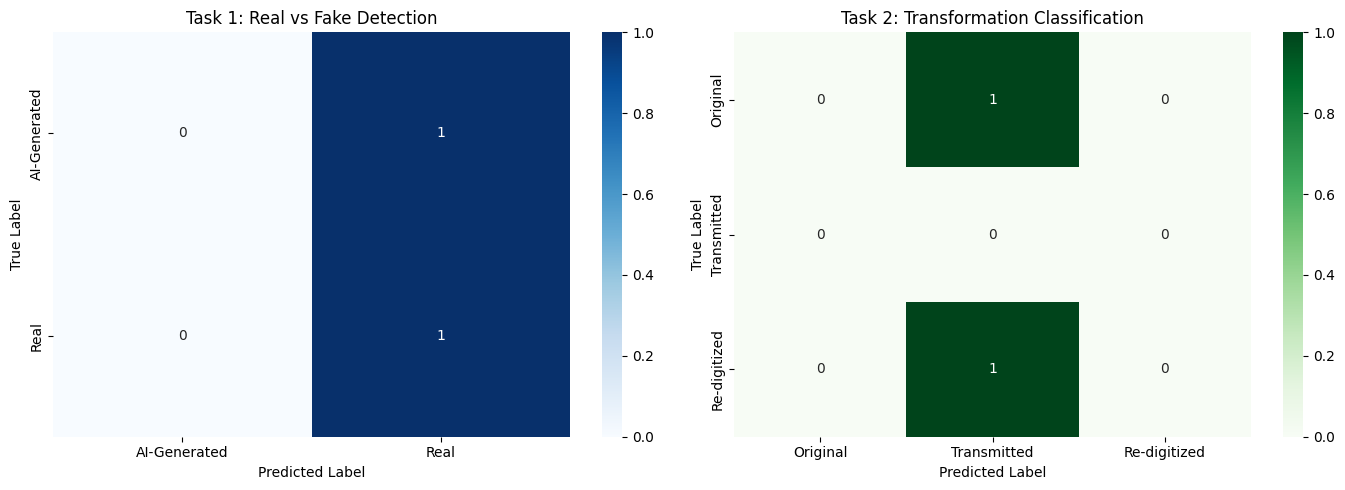

Saved: confusion_matrices.png


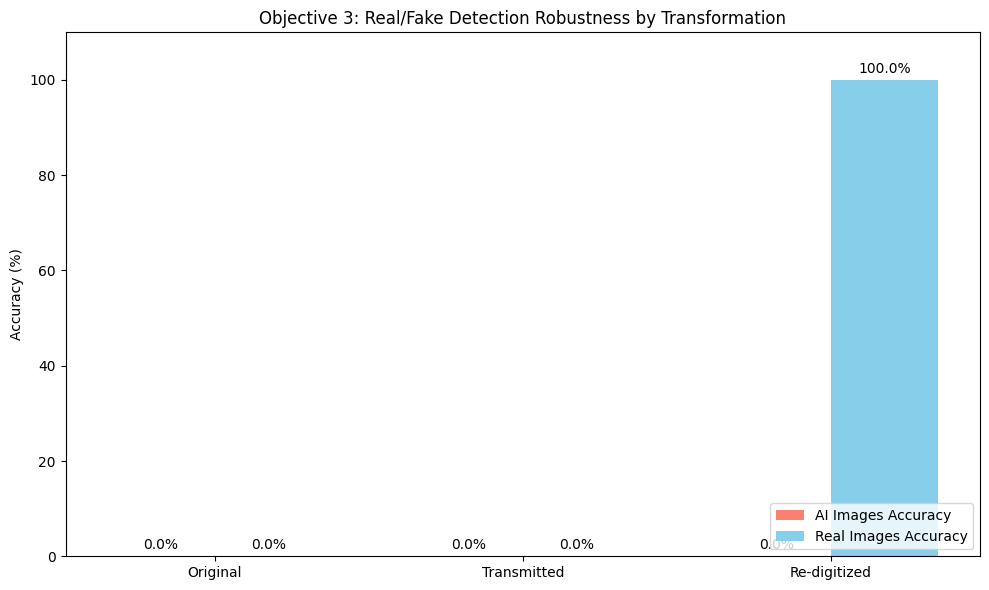

Saved: accuracy_breakdown.png


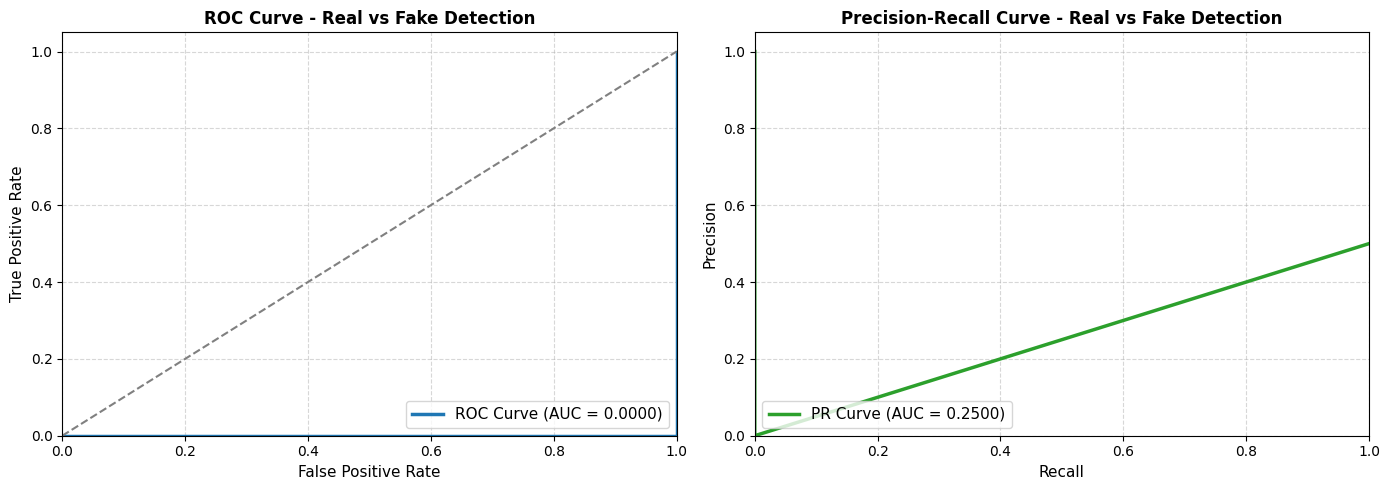

Saved: roc_pr_curves.png


/Users/francescoinnocenzi/git/DeepFakeDetection/src/evaluation/visualizer.py:222: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(ai_probs, fill=True, color='salmon', label='AI-Generated (True 0)', ax=ax, alpha=0.5, bw_adjust=0.5)
/Users/francescoinnocenzi/git/DeepFakeDetection/src/evaluation/visualizer.py:223: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(real_probs, fill=True, color='skyblue', label='Real Images (True 1)', ax=ax, alpha=0.5, bw_adjust=0.5)


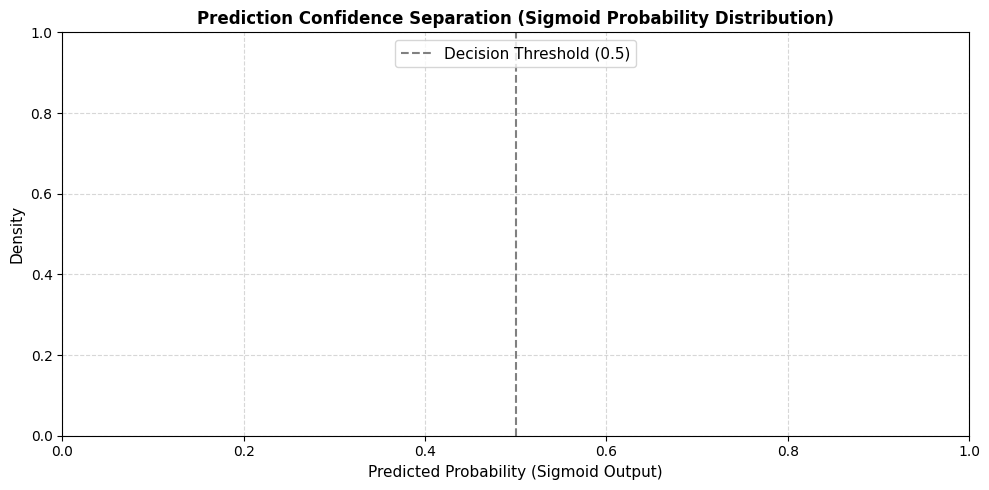

Saved: prediction_distribution.png
Grading 0.5_0.5...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Grading uncertainty...
Shape mismatch for frequency_backbone.features.0.weight: checkpoint shape torch.Size([64, 6, 3, 3]), model shape torch.Size([32, 6, 3, 3]). Excluding this key from loading.
Shape mismatch for frequency_backbone.features.0.bias: checkpoint shape torch.Size([64]), model shape torch.Size([32]). Excluding this key from loading.
Shape mismatch for frequency_backbone.features.1.weight: checkpoint shape torch.Size([64]), model shape torch.Size([32]). Excluding this key from loading.
Shape mismatch for frequency_backbone.features.1.bias: checkpoint shape torch.Size([64]), model shape torch.Size([32]). Excluding this key from loading.
Shape mismatch for frequency_backbone.features.1.running_mean: checkpoint shape torch.Size([64]), model shape torch.Size([32]). Excluding this key from loading.
Shape mismatch for frequency_backbone.features.1.running_var: checkpoint shape torch.Size([64]), model shape torch.Size([32]). Excluding this key from loading.
Shape mismatch for fre

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


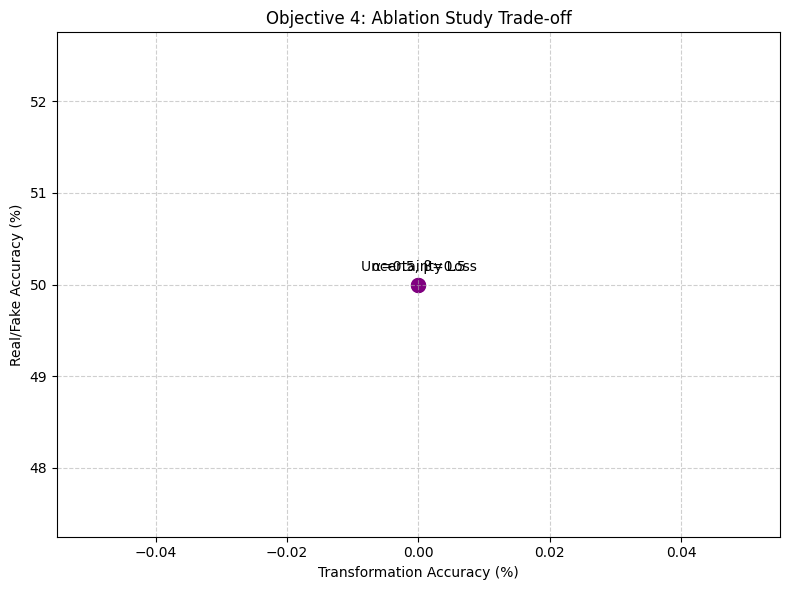

Saved: ablation_study.png


In [5]:
import os
import torch
import importlib
import src.evaluation.visualizer as visualizer
#importlib.reload(visualizer)
from src.globals import LOSS_TYPE
from src.train.loops import MultiTaskModel
from src.evaluation.visualizer import evaluate_model, plot_ablation_study

best_model = MultiTaskModel().to(device)

# 1. Evaluate the active model checkpoint corresponding to LOSS_TYPE
model_path = "models/model_uncertainty.pth" if LOSS_TYPE == 'uncertainty' else "models/model_05_05.pth"
print(f"Loading active checkpoint from {model_path}...")
best_model.load_state_dict(torch.load(model_path, map_location=device))

evaluate_model(best_model, test_loader, device)

# 2. Plot the ablation study comparing available model checkpoints
available_models = {
    #'1.0_0.0': 'models/model_10_00.pth',
    #'0.0_1.0': 'models/model_00_10.pth',
    '0.5_0.5': 'models/model_05_05.pth',
    #'0.8_0.2': 'models/model_08_02.pth',
    #'0.2_0.8': 'models/model_02_08.pth',
    'uncertainty': 'models/model_uncertainty.pth'
}

real_ablation_results = {}

for weight_key, file_path in available_models.items():
    if os.path.exists(file_path):
        print(f"Grading {weight_key}...")
        temp_model = MultiTaskModel().to(device)
        temp_model.load_state_dict(torch.load(file_path, map_location=device))
        acc_rf, acc_trans = evaluate_model(temp_model, test_loader, device, quiet_mode=True)
        real_ablation_results[weight_key] = (acc_rf * 100, acc_trans * 100)

# Draw the final graph comparing all available models
plot_ablation_study(real_ablation_results)


Running backbone comparison on device: cpu

Evaluating ResNet-50 (resnet50) from models/model_05_05.pth...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Evaluating ConvNeXt-Tiny (convnext_tiny) from models/model_convnext_tiny_05_05.pth...


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Backbone         | RF Acc (%)   | TF Acc (%)   | F1 Score   | ROC AUC   
ResNet-50        | 50.00        | 0.00         | 0.6667     | 0.0000    
ConvNeXt-Tiny    | 100.00       | 0.00         | 1.0000     | 1.0000    


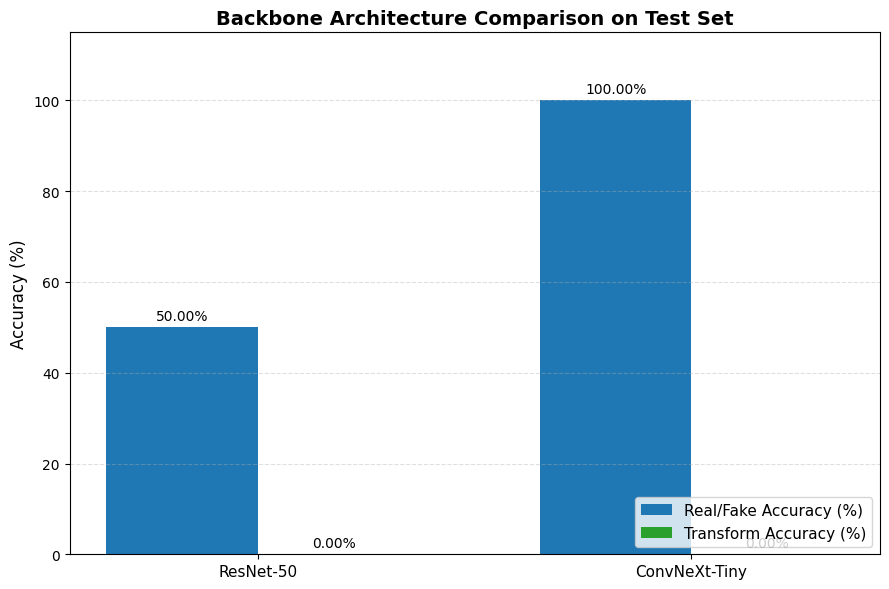


Saved comparison plot to backbone_comparison.png


In [6]:
# --- Backbone Architecture Comparison ---
from src.evaluation.compare_backbones import compare_backbone_checkpoints
models_to_compare = {
    "ResNet-50": ("resnet50", "models/model_05_05.pth"),
    "ConvNeXt-Tiny": ("convnext_tiny", "models/model_convnext_tiny_05_05.pth"),
    # "ConvNeXt-Base": ("convnext_base", "models/model_convnext_base_05_05.pth") # uncomment if trained
}
comparison_results = compare_backbone_checkpoints(models_to_compare, test_loader=test_loader)

IndexError: index 1 is out of bounds for dimension 0 with size 1

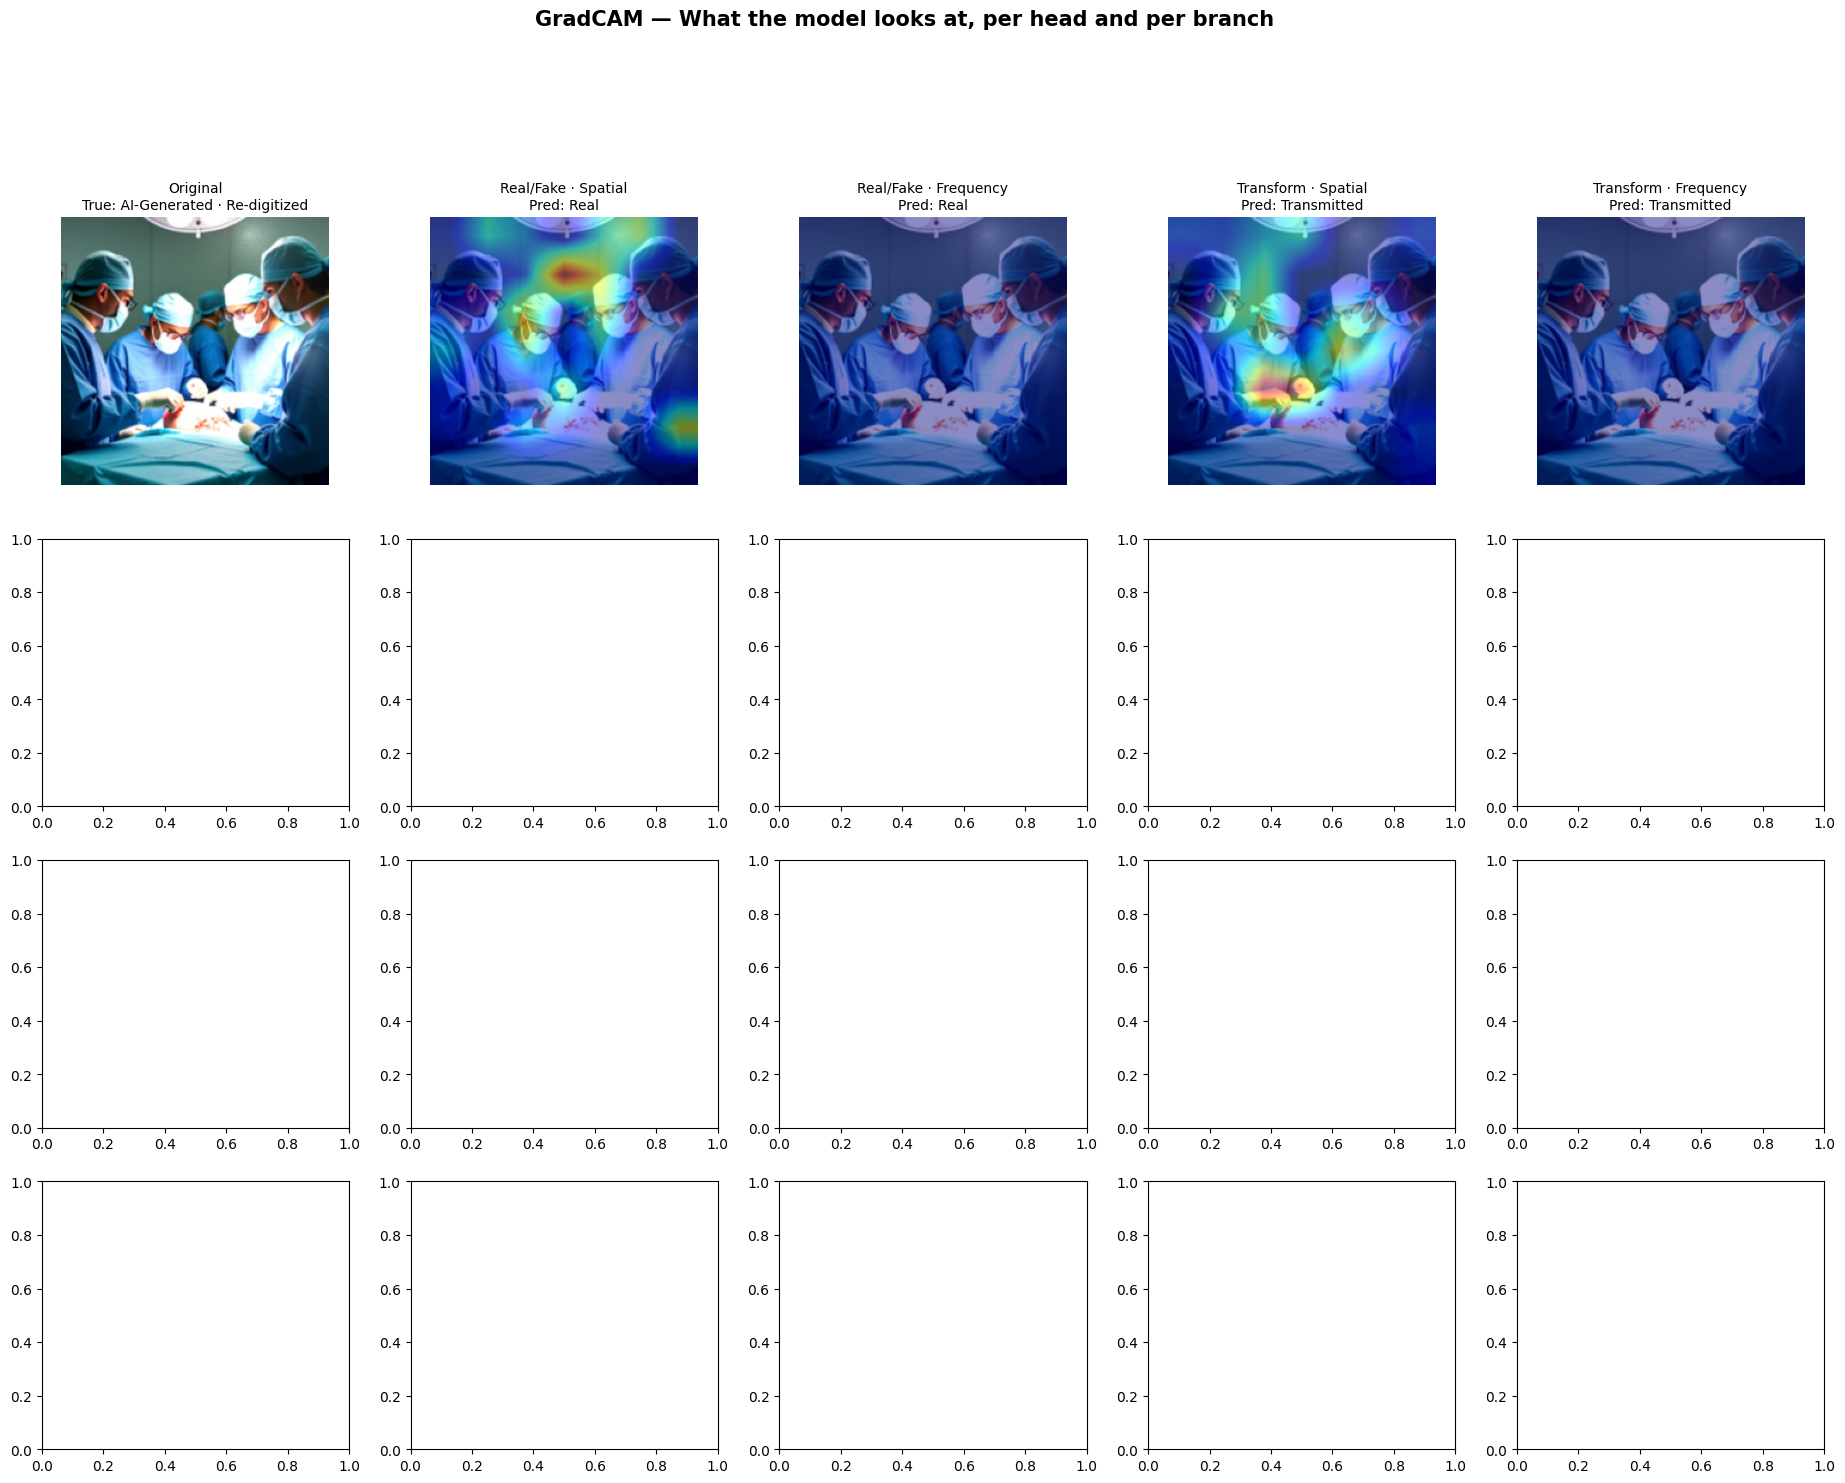

In [7]:
# --- GradCAM Visualization for ConvNeXt-Tiny ---
from src.evaluation.visualizer import plot_gradcam
from src.train.loops import MultiTaskModel
convnext_model = MultiTaskModel(backbone_type='convnext_tiny').to(device)
convnext_model.load_state_dict(torch.load("models/model_convnext_tiny_05_05.pth", map_location=device))
plot_gradcam(convnext_model, val_loader, device, num_samples=4)